# PCA clásico vs Kernel PCA: un ejemplo con datos sintéticos

Ejemplo para el curso de aprendizaje de máquinas no supervisado de la Especialización
de Machine Learning de la Universidad del Magdalena.

En el ejemplo con MNIST vimos que PCA clásico y Kernel PCA producían representaciones
visualmente parecidas, y que no fue necesario escalar los datos porque todos los
píxeles compartían la misma escala. Aquí utilizamos un conjunto de datos sintético de
10 variables diseñado para mostrar dos cosas que allí no ocurrieron:

1. La necesidad de escalar: las variables de este conjunto tienen escalas muy
   distintas (como ocurre cuando se miden en unidades diferentes), y veremos que sin
   escalarlas tanto PCA como Kernel PCA producen representaciones inservibles.
2. Una estructura que PCA clásico no puede revelar por ser un método lineal, pero
   Kernel PCA sí.

La idea del ejemplo: los datos tienen una estructura de dos anillos concéntricos que
vive en un plano de un espacio de 10 dimensiones. Como un anillo rodea al otro,
ninguna proyección lineal (ninguna "sombra" de los datos) puede separar los dos
grupos; para lograrlo se necesita una transformación no lineal.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler

%matplotlib inline

## 1. Carga y visualización de los datos

El archivo `datos_sinteticos_anillos.csv` (en esta misma carpeta) contiene 1000
ejemplos con 10 variables (`var_1` a `var_10`) y una columna adicional `grupo` que
indica a qué anillo pertenece cada punto.

Los datos fueron generados sintéticamente con esta estructura: dos anillos
concéntricos en un plano (grupo 0: anillo exterior, grupo 1: anillo interior),
8 variables adicionales de ruido con poca varianza, y una rotación en el espacio de
10 dimensiones que reparte la estructura entre todas las variables. Además, dos de
las variables (`var_3` y `var_8`) están expresadas en unidades distintas a las demás,
por lo que sus valores son cientos o miles de veces más grandes. El script
`generar_datos_sinteticos_anillos.py` de esta carpeta permite regenerarlos o
modificarlos.

La columna `grupo` se usa únicamente para colorear las gráficas: ni PCA ni Kernel PCA
la utilizan, ambos son métodos no supervisados.

In [6]:
# Cargamos el conjunto de datos sintético
datos = pd.read_csv('datos_sinteticos_anillos.csv')

# Separamos las 10 variables (X) de la etiqueta de grupo (y)
X = datos.drop(columns='grupo')
y = datos['grupo'].values

print("Dimensiones del conjunto de datos:", X.shape)
datos.info()

Dimensiones del conjunto de datos: (1000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   var_1   1000 non-null   float64
 1   var_2   1000 non-null   float64
 2   var_3   1000 non-null   float64
 3   var_4   1000 non-null   float64
 4   var_5   1000 non-null   float64
 5   var_6   1000 non-null   float64
 6   var_7   1000 non-null   float64
 7   var_8   1000 non-null   float64
 8   var_9   1000 non-null   float64
 9   var_10  1000 non-null   float64
 10  grupo   1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


In [4]:
print(X.describe())

             var_1        var_2        var_3        var_4        var_5  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.000242     0.000208    -0.030552     0.000320     0.000022   
std       0.053139     0.138168     3.127239     0.202942     0.080857   
min      -0.161038    -0.323104    -8.712179    -0.424907    -0.190102   
25%      -0.033084    -0.076927    -2.113730    -0.111684    -0.048964   
50%       0.001903    -0.000087    -0.150649    -0.003254    -0.002381   
75%       0.035064     0.080786     2.185035     0.114481     0.049204   
max       0.142911     0.299356    10.111463     0.448121     0.183342   

             var_6        var_7        var_8        var_9       var_10  
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000  
mean      0.000734    -0.001977     0.185379     0.000421     0.000416  
std       0.239389     0.176741   438.564205     0.359733     0.262753  
min      -0.532135    -0.393243  -938.338

In [7]:
# Observe la desviación estándar de cada variable: var_3 y var_8 son más grandes que las demás
X.std().round(2)

var_1       0.05
var_2       0.14
var_3       3.13
var_4       0.20
var_5       0.08
var_6       0.24
var_7       0.18
var_8     438.56
var_9       0.36
var_10      0.26
dtype: float64

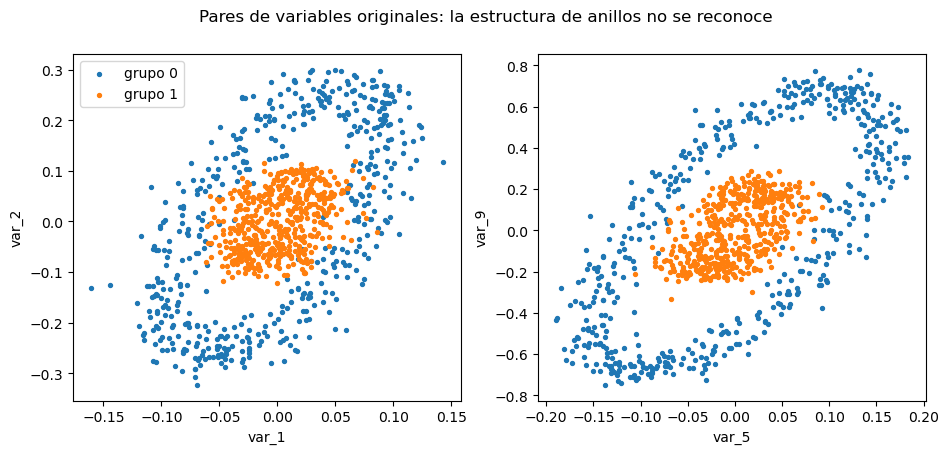

In [8]:
# Si miramos pares de variables originales la estructura de anillos es difícil
# de reconocer: la rotación la repartió entre las 10 variables (a lo sumo se
# intuye una mezcla difusa de los dos grupos)
fig, ejes = plt.subplots(1, 2, figsize=(11, 4.5))
for c, nombre in [(0, 'grupo 0'), (1, 'grupo 1')]:
    ejes[0].scatter(X.loc[y == c, 'var_1'], X.loc[y == c, 'var_2'], s=8, label=nombre)
    ejes[1].scatter(X.loc[y == c, 'var_5'], X.loc[y == c, 'var_9'], s=8, label=nombre)
ejes[0].set_xlabel('var_1'); ejes[0].set_ylabel('var_2')
ejes[1].set_xlabel('var_5'); ejes[1].set_ylabel('var_9')
ejes[0].legend()
plt.suptitle('Pares de variables originales: la estructura de anillos no se reconoce')
plt.show()

## 2. PCA clásico sin escalar

Apliquemos primero PCA directamente sobre los datos, sin ningún preprocesamiento,
para ver qué ocurre. Recuerde que PCA busca las direcciones de mayor varianza; como
`var_3` y `var_8` tienen valores cientos o miles de veces más grandes que el resto,
su varianza domina por completo el análisis.

Varianza explicada por las 2 primeras componentes: 100.00 %


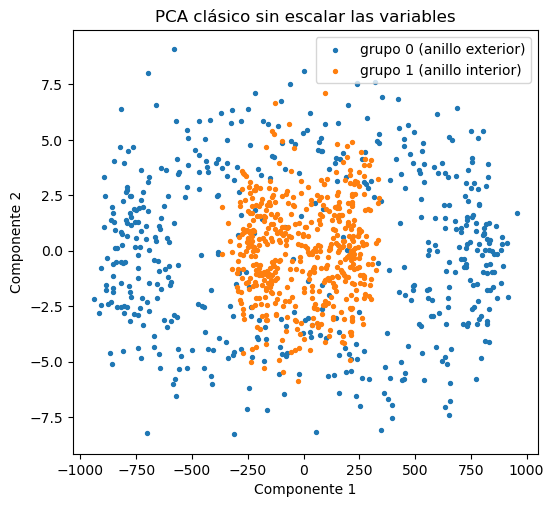

In [9]:
pca_sin_escalar = PCA(n_components=2)
X_pca_sin_escalar = pca_sin_escalar.fit_transform(X)

print('Varianza explicada por las 2 primeras componentes: %.2f %%'
      % (100 * pca_sin_escalar.explained_variance_ratio_.sum()))

plt.figure(figsize=(6, 5.5))
for c, nombre in [(0, 'grupo 0 (anillo exterior)'), (1, 'grupo 1 (anillo interior)')]:
    plt.scatter(X_pca_sin_escalar[y == c, 0], X_pca_sin_escalar[y == c, 1],
                s=8, label=nombre)
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('PCA clásico sin escalar las variables')
plt.legend()
plt.show()

El resultado es una nube sin estructura: las dos componentes quedaron dominadas por
`var_8` y `var_3` (observe las magnitudes de los ejes), que son puro ruido en unidades
grandes, y la estructura de anillos quedó aplastada.

Note un detalle importante: la varianza explicada por las 2 componentes es
prácticamente del 100%, el valor más alto posible, y sin embargo la representación es
inservible. La varianza explicada se mide en las unidades de los datos, así que cuando
las escalas son heterogéneas deja de ser un buen indicador de calidad: explicar mucha
varianza solo significa reproducir las variables de números grandes.

## 3. Escalado de las variables

La solución es llevar todas las variables a una escala comparable antes de aplicar
PCA. Usamos `StandardScaler`, que resta a cada variable su media y la divide por su
desviación estándar, de modo que todas quedan con media 0 y desviación estándar 1.
Así ninguna variable domina el análisis solo por sus unidades de medida.

Varianza explicada por las 2 primeras componentes: 94.19 %


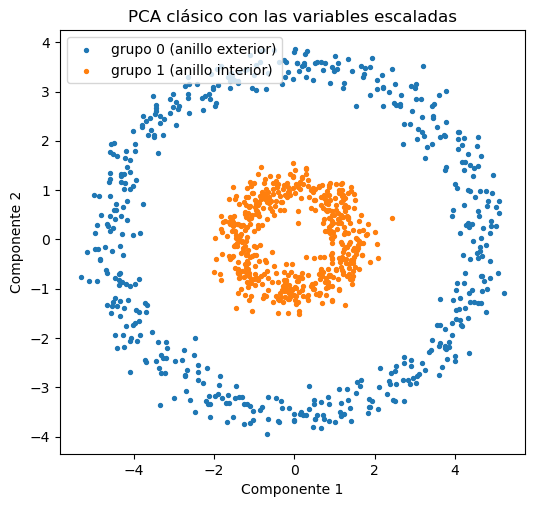

In [10]:
# Escalamos las variables: media 0 y desviación estándar 1 para cada una
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

# Repetimos el PCA, ahora sobre los datos escalados
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_escalado)

print('Varianza explicada por las 2 primeras componentes: %.2f %%'
      % (100 * pca.explained_variance_ratio_.sum()))

plt.figure(figsize=(6, 5.5))
for c, nombre in [(0, 'grupo 0 (anillo exterior)'), (1, 'grupo 1 (anillo interior)')]:
    plt.scatter(X_pca[y == c, 0], X_pca[y == c, 1], s=8, label=nombre)
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('PCA clásico con las variables escaladas')
plt.legend()
plt.show()

Con las variables escaladas el panorama cambia por completo: PCA recuperó la
estructura de anillos que estaba escondida entre las 10 variables y dejó de lado las
dimensiones de ruido. Sin embargo, observe que los grupos siguen siendo inseparables:
un anillo rodea al otro. Esto no es un defecto de esta proyección en particular; como
PCA solo puede aplicar transformaciones lineales (rotaciones y proyecciones), y en
toda proyección lineal el anillo exterior seguirá rodeando al interior, no existe
ninguna elección de componentes que separe los dos grupos.

## 4. Kernel PCA

Aplicamos ahora Kernel PCA con kernel gaussiano (RBF). El kernel mide la similitud
entre puntos en términos de distancia: puntos de un mismo anillo están cerca entre sí
y lejos de los del otro anillo. Al hacer PCA sobre esa noción de similitud, el método
puede "desenrollar" los anillos y separarlos.

Como el kernel se calcula con las distancias entre puntos, Kernel PCA es igual de
sensible a las escalas que el PCA clásico: sin escalar, las distancias quedarían
dominadas por `var_3` y `var_8` y el resultado sería inservible. Por eso lo aplicamos
sobre los datos ya escalados.

El parámetro `gamma` controla el ancho del kernel gaussiano (qué tan rápido decae la
similitud con la distancia); más adelante veremos que su elección es importante.

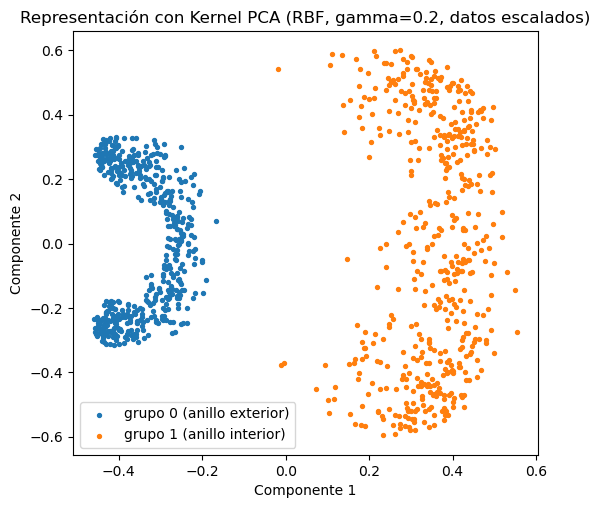

In [11]:
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.2)
X_kpca = kpca.fit_transform(X_escalado)

plt.figure(figsize=(6, 5.5))
for c, nombre in [(0, 'grupo 0 (anillo exterior)'), (1, 'grupo 1 (anillo interior)')]:
    plt.scatter(X_kpca[y == c, 0], X_kpca[y == c, 1], s=8, label=nombre)
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Representación con Kernel PCA (RBF, gamma=0.2, datos escalados)')
plt.legend()
plt.show()

Con la representación de Kernel PCA los dos anillos quedaron convertidos en dos grupos
compactos y separados: la primera componente por sí sola basta para distinguirlos.

Para verlo con claridad, comparamos la distribución de la primera componente de cada
método separada por grupo.

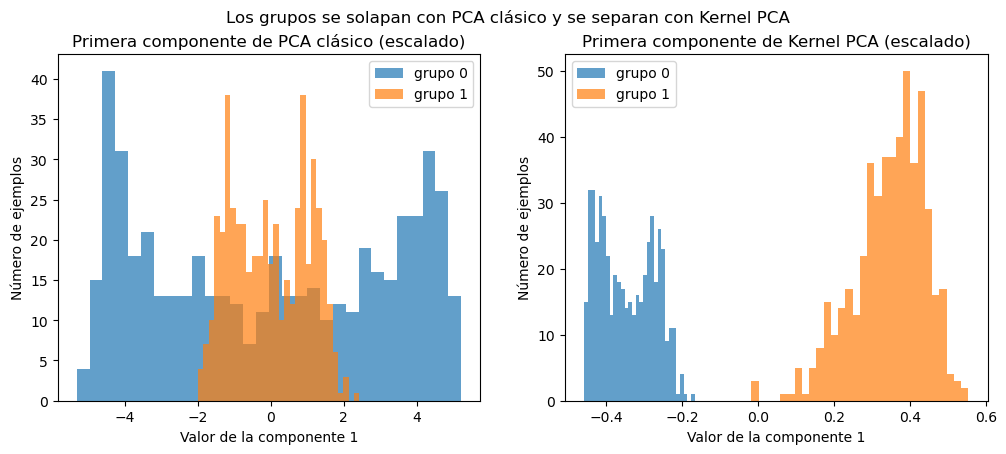

In [12]:
# Histograma de la primera componente de cada metodo, separado por grupo
# (ambos metodos aplicados sobre los datos escalados)
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

for c, nombre in [(0, 'grupo 0'), (1, 'grupo 1')]:
    ejes[0].hist(X_pca[y == c, 0], bins=30, alpha=0.7, label=nombre)
    ejes[1].hist(X_kpca[y == c, 0], bins=30, alpha=0.7, label=nombre)

ejes[0].set_title('Primera componente de PCA clásico (escalado)')
ejes[1].set_title('Primera componente de Kernel PCA (escalado)')
for eje in ejes:
    eje.set_xlabel('Valor de la componente 1')
    eje.set_ylabel('Número de ejemplos')
    eje.legend()
plt.suptitle('Los grupos se solapan con PCA clásico y se separan con Kernel PCA')
plt.show()

## 5. La elección del kernel y sus parámetros importa

La ventaja de Kernel PCA no es automática: depende de elegir un kernel y unos
parámetros adecuados para los datos. Repetimos el ejercicio con tres valores de
`gamma`: uno muy pequeño (el kernel es casi lineal y el resultado se parece al PCA
clásico), el valor adecuado, y uno muy grande (cada punto solo se parece a sus
vecinos inmediatos y la estructura global se pierde).

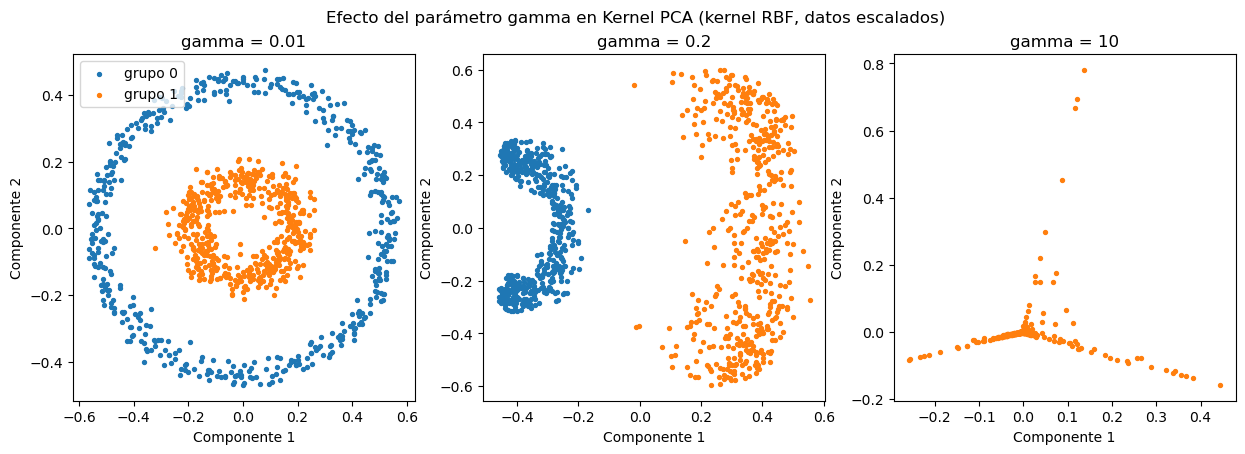

In [13]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.5))

for eje, g in zip(ejes, [0.01, 0.2, 10]):
    X_g = KernelPCA(n_components=2, kernel='rbf', gamma=g).fit_transform(X_escalado)
    for c, nombre in [(0, 'grupo 0'), (1, 'grupo 1')]:
        eje.scatter(X_g[y == c, 0], X_g[y == c, 1], s=8, label=nombre)
    eje.set_title('gamma = %g' % g)
    eje.set_xlabel('Componente 1')
    eje.set_ylabel('Componente 2')
ejes[0].legend()
plt.suptitle('Efecto del parámetro gamma en Kernel PCA (kernel RBF, datos escalados)')
plt.show()

### Interpretación de los tres resultados

Para interpretar las tres gráficas conviene recordar qué mide el kernel RBF:
$k(x, x') = e^{-\gamma \, \lVert x - x' \rVert^2}$, la similitud entre dos puntos, que
decae con la distancia entre ellos a una velocidad controlada por `gamma`. De forma
aproximada, dos puntos se consideran "parecidos" cuando su distancia es menor que
$1/\sqrt{\gamma}$; ese valor actúa como el radio de influencia de cada punto.

Como referencia, en el espacio escalado los anillos tienen radios aproximados de 4
(exterior) y 1.3 (interior), así que la separación entre ellos es de unas 2.5 a 3
unidades.

- Con `gamma = 0.01` el radio de influencia es de alrededor de 10 unidades, más
  grande que cualquier distancia en estos datos. Todos los puntos resultan parecidos
  entre sí, el kernel apenas distingue distancias y su comportamiento es casi lineal:
  el resultado reproduce los anillos concéntricos del PCA clásico, sin ganancia
  alguna.

- Con `gamma = 0.2` el radio de influencia es de alrededor de 2 unidades, un valor
  comparable con la separación entre los anillos. Cada punto es similar a los de su
  propio anillo y poco similar a los del otro; esa es exactamente la información que
  el método necesita para separar los dos grupos en la primera componente.

- Con `gamma = 10` el radio de influencia cae a unas 0.3 unidades: cada punto solo
  se parece a sus vecinos inmediatos y resulta casi igual de "distinto" a todos los
  demás, estén en su anillo o en el otro. La noción de estructura global se pierde y
  la representación se degrada: un grupo colapsa en una nube compacta y el otro se
  dispersa sin orden. El resultado es peor que el del PCA clásico.

La lectura general: `gamma` debe estar en sintonía con la escala de las distancias
que definen la estructura de los datos. Ni tan pequeño que todo parezca igual de
similar, ni tan grande que nada lo parezca. Observe además que escalar los datos
también ayuda aquí: al llevar todas las variables a una escala comparable, las
distancias (y por tanto `gamma`) tienen un significado uniforme. En la práctica se
explora un rango de valores (como hicimos aquí) o se selecciona con algún criterio
de validación.

## Conclusiones

- Cuando las variables tienen escalas muy distintas, aplicar PCA sin escalar produce
  una representación dominada por las variables de números grandes. La varianza
  explicada puede ser altísima y aun así la representación resultar inservible: con
  escalas heterogéneas ese indicador deja de ser confiable.
- El escalado (aquí con `StandardScaler`) es necesario tanto para PCA clásico como
  para Kernel PCA, porque ambos dependen de las magnitudes de los datos (el primero
  a través de la varianza, el segundo a través de las distancias). En MNIST no fue
  necesario porque todos los píxeles compartían la misma escala.
- Con los datos escalados, PCA clásico hizo lo que puede hacer un método lineal:
  encontró el plano de mayor varianza y descartó las dimensiones de ruido, pero no
  puede separar grupos que no son linealmente separables.
- Kernel PCA, con el kernel y el parámetro adecuados, transformó los anillos
  concéntricos en dos grupos compactos y separables con una sola componente.
- La ventaja del método no lineal depende críticamente de la elección del kernel y
  de sus parámetros: con un `gamma` inadecuado el resultado puede ser igual o peor
  que el del PCA clásico.
- En datos reales (como vimos con MNIST) la estructura no siempre es tan no lineal
  como en este ejemplo diseñado a propósito; por eso conviene comparar ambos métodos.

Actividad propuesta: aplique Kernel PCA directamente sobre los datos sin escalar y
observe el resultado. Luego regenere los datos con los anillos más cercanos entre sí
usando el script `generar_datos_sinteticos_anillos.py` (cambie `factor=0.3` por
`factor=0.7`), vuelva a ejecutar el notebook y observe cómo cambia la representación
de ambos métodos y qué tan sensible se vuelve la elección de `gamma`.